## Column Transformer

When a dataset contains different types of features such as numerical, categorical, and binary columns, applying preprocessing manually becomes inefficient.

ColumnTransformer allows us to apply different transformations to different columns in a single pipeline.

This ensures that preprocessing steps are applied consistently during both training and testing.

## 1. Import Libraries and Dataset

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')
# Clean 'TotalCharges' column: replace empty strings with NaN, convert to numeric, and fill NaN with 0
df['TotalCharges'] = df['TotalCharges'].replace(' ', pd.NA)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Identify Feature Types

Here, we have so many data types columns


In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
num_cols = ['tenure','MonthlyCharges','TotalCharges']
cat_cols = ['InternetService','PaymentMethod','Contract']
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling']


## 3. Separate the Training and Testing Data

In [6]:
X = df.drop(columns=['customerID','Churn'])
y = df['Churn']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## 4. Apply ColumnTransformer

ColumnTransformer helps apply different preprocessing techniques to different subsets of columns.

For example:
- Numerical features → StandardScaler
- Categorical features → OneHotEncoder
- Binary features → Passed without transformation

In [8]:
col_trans = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols),
        ('binary', OrdinalEncoder(), binary_cols)
    ]
)

In [9]:
X_train_transformed = col_trans.fit_transform(X_train)
X_test_transformed = col_trans.transform(X_test)

## 5. Feature Distribution Before and After Scaling

1. To understand how scaling affects  features, we visualize the distribution of a feature before and after applying the transformation on X_train.

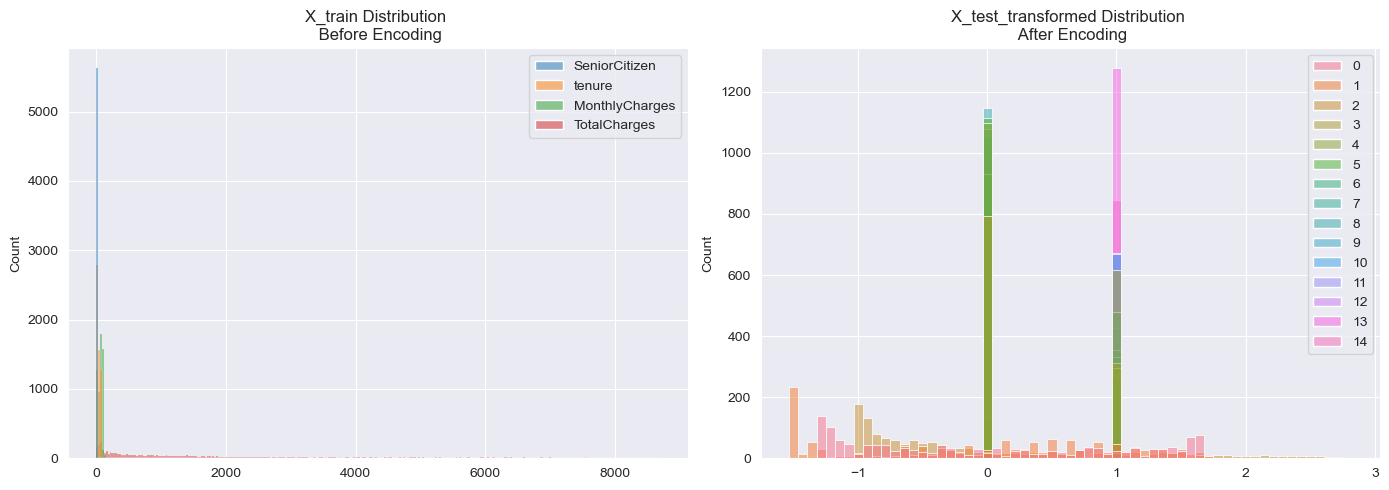

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot the first histogram on the first axes (ax[0])
sns.histplot(X_train, ax=ax[0])
ax[0].set_title('X_train Distribution \n Before Encoding') # Add title for clarity

# Plot the second histogram on the second axes (ax[1])
sns.histplot(X_test_transformed, ax=ax[1])
ax[1].set_title('X_test_transformed Distribution \n After Encoding') # Add title for clarity

plt.tight_layout() # Adjust layout to prevent titles from overlapping
plt.show()

2. To understand how scaling affects numerical features, we visualize the distribution of a feature before and after applying the transformation.

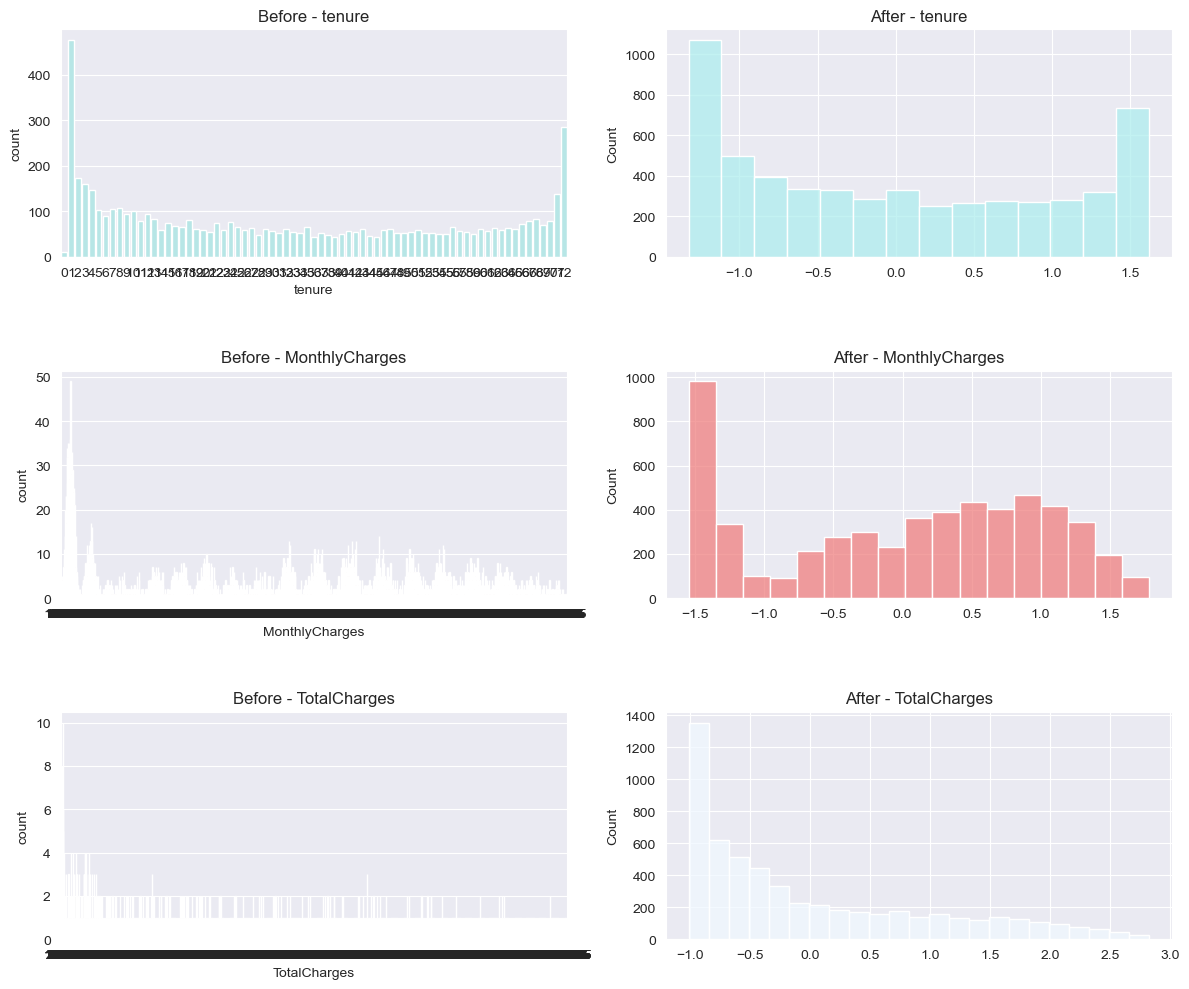

In [11]:
colors = ['paleturquoise','lightcoral','aliceblue','lightgray','burlywood','khaki','plum']
fig, axes = plt.subplots(len(num_cols), 2, figsize=(12,10))

for i, col in enumerate(num_cols):
        # Before Encoding
        sns.countplot(x=X_train[col], ax=axes[i,0], color=colors[i])
        axes[i,0].set_title(f'Before - {col}')

        # After Encoding
        sns.histplot(X_train_transformed[:, i], ax=axes[i,1], color=colors[i % len(colors)])
        axes[i,1].set_title(f'After - {col}')
plt.tight_layout()
plt.subplots_adjust(hspace=0.5)
plt.show()

3. To understand how scaling affects categorical features, we visualize the distribution of a feature before and after applying the transformation.

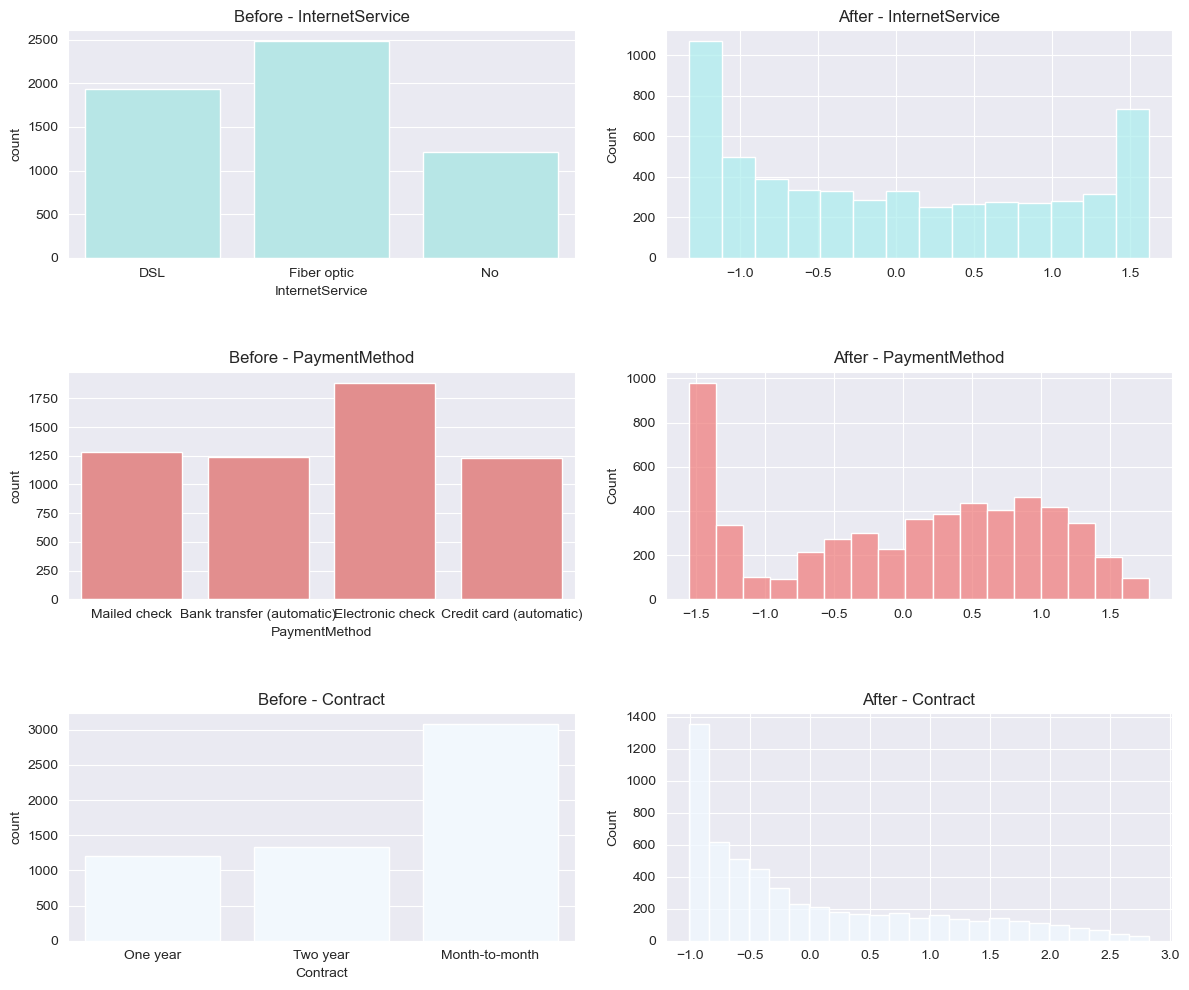

In [12]:
fig, axes = plt.subplots(len(cat_cols), 2, figsize=(12,10))

for i, col in enumerate(cat_cols):
        # Before Encoding
        sns.countplot(x=X_train[col], ax=axes[i,0], color=colors[i])
        axes[i,0].set_title(f'Before - {col}')

        # After Encoding
        sns.histplot(X_train_transformed[:, i], ax=axes[i,1], color=colors[i % len(colors)])
        axes[i,1].set_title(f'After - {col}')
plt.tight_layout()
plt.subplots_adjust(hspace=0.5)
plt.show()

4. Binary columns already contain values like 0 and 1 or Yes/No.
Therefore, they can be passed through the pipeline without transformation.

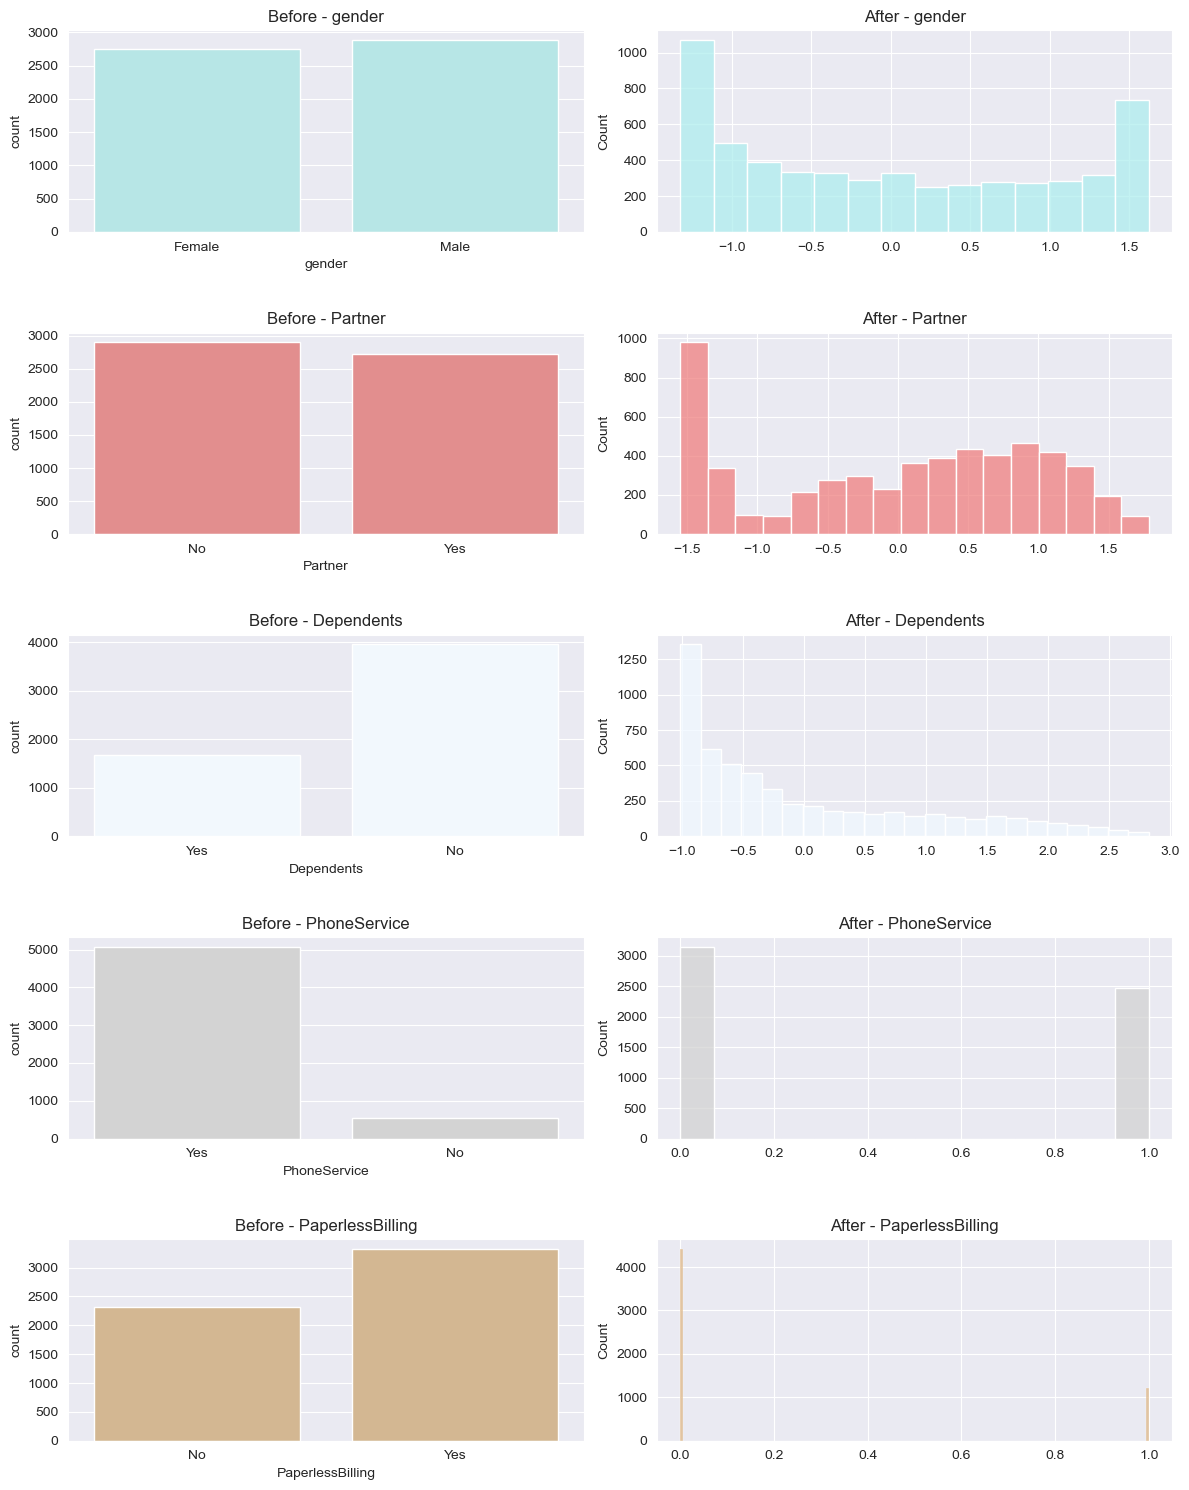

In [13]:
fig, axes = plt.subplots(len(binary_cols), 2, figsize=(12,15))

for i, col in enumerate(binary_cols):
        # Before Encoding
        sns.countplot(x=X_train[col], ax=axes[i,0], color=colors[i])
        axes[i,0].set_title(f'Before - {col}')

        # After Encoding
        sns.histplot(X_train_transformed[:, i], ax=axes[i,1], color=colors[i % len(colors)])
        axes[i,1].set_title(f'After - {col}')
plt.tight_layout()
plt.subplots_adjust(hspace=0.5)
plt.show()

## 6. Model Implementation

In this dataset I used `LogisticRegression`.

In [14]:
lr = LogisticRegression(max_iter=500, class_weight='balanced')

lr.fit(X_train_transformed, y_train)
y_pred = lr.predict(X_test_transformed)

## 7. Model Evaluation
After applying  `class_weight = "balanced"`, the model becomes more sensitive to the minority class (churn customers).

Although the overall accuracy slightly decreases, the recall for churn customers significanlty improves from `0.59` to `0.84`.

This trade-off is acceptable in churn prediction problems because identifying potential churn customers is more important than maximizing overall accuracy.

In [15]:
print("Accuracy score is: ", accuracy_score(y_test, y_pred))

Accuracy score is:  0.7480482611781405


In [16]:
from sklearn.metrics import confusion_matrix

cn = confusion_matrix(y_test, y_pred)
print("Confusion Matrix : ",cn)

Confusion Matrix :  [[742 294]
 [ 61 312]]


In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.92      0.72      0.81      1036
         Yes       0.51      0.84      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.82      0.75      0.76      1409



In [18]:
from sklearn.metrics import roc_auc_score

print("ROC AUC score is: ", roc_auc_score(y_test, lr.predict_proba(X_test_transformed)[:,1]))

ROC AUC score is:  0.8600554307658865
